<a href="https://colab.research.google.com/github/lbolte2001/COGS181FinalProject/blob/main/COGS181_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import packages
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms

In [2]:
#load tinyimage net dataset
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip

--2026-03-19 15:31:08--  http://cs231n.stanford.edu/tiny-imagenet-200.zip
Resolving cs231n.stanford.edu (cs231n.stanford.edu)... 171.64.64.64
Connecting to cs231n.stanford.edu (cs231n.stanford.edu)|171.64.64.64|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://cs231n.stanford.edu/tiny-imagenet-200.zip [following]
--2026-03-19 15:31:09--  https://cs231n.stanford.edu/tiny-imagenet-200.zip
Connecting to cs231n.stanford.edu (cs231n.stanford.edu)|171.64.64.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248100043 (237M) [application/zip]
Saving to: ‘tiny-imagenet-200.zip’

tiny-imagenet-200.z 100%[===================>] 236.61M  31.9MB/s    in 7.8s    

2026-03-19 15:31:17 (30.1 MB/s) - ‘tiny-imagenet-200.zip’ saved [248100043/248100043]



In [3]:
!unzip -q tiny-imagenet-200.zip

In [4]:
#load training set
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root='tiny-imagenet-200/train',
    transform=transform
)

In [5]:
#restructure image file setup in validation set
import shutil

val_dir = 'tiny-imagenet-200/val'
img_dir = os.path.join(val_dir, 'images')
anno_file = os.path.join(val_dir, 'val_annotations.txt')

#Move images into class folders
with open(anno_file, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        img_name = parts[0]
        class_name = parts[1]

        class_dir = os.path.join(val_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        src_path = os.path.join(img_dir, img_name)
        dst_path = os.path.join(class_dir, img_name)

        if os.path.exists(src_path):
            shutil.move(src_path, dst_path)

#remove empty images folder
if os.path.exists(img_dir):
    os.rmdir(img_dir)

In [6]:
#reload validation set
val_dataset = datasets.ImageFolder(
    root='tiny-imagenet-200/val',
    transform=transform
)

In [7]:
#sanity check for image formatting
import os
print(os.listdir('tiny-imagenet-200/val')[:5])

['n09193705', 'n04560804', 'n04179913', 'n07875152', 'n02948072']


In [8]:
#normalization
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(64),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [9]:
train_dataset = datasets.ImageFolder(
    root='tiny-imagenet-200/train',
    transform=transform_train
)

val_dataset = datasets.ImageFolder(
    root='tiny-imagenet-200/val',
    transform=transform_val
)

In [10]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

dataloaders = {
    'train': train_loader,
    'val': val_loader
}

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#define first frozen baseline model - AdamW optimizer
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


In [11]:
#define training loop
def train_model(model, dataloaders, criterion, optimizer, scheduler, device, num_epochs=10):
    train_losses = []
    val_losses = []
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()


            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'train':
                train_losses.append(epoch_loss)
            else:
                val_losses.append(epoch_loss)
        scheduler.step()

    return model, train_losses, val_losses

In [14]:

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.fc = nn.Linear(model.fc.in_features, 200)
model = model.to(device)

# ✅ NOW define optimizer (only trains fc)
optimizer = optim.AdamW(model.fc.parameters(), lr=3e-4)
#define loss and scheduler
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


In [15]:
model , train_losses, val_losses = train_model(
    model,
    dataloaders,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=10
)


Epoch 1/10
--------------------
train Loss: 3.9419 Acc: 0.1973
val Loss: 3.3172 Acc: 0.2843

Epoch 2/10
--------------------
train Loss: 3.3068 Acc: 0.2859
val Loss: 3.1320 Acc: 0.3226

Epoch 3/10
--------------------
train Loss: 3.2061 Acc: 0.3013
val Loss: 3.1110 Acc: 0.3232

Epoch 4/10
--------------------
train Loss: 3.1500 Acc: 0.3116
val Loss: 3.0965 Acc: 0.3292

Epoch 5/10
--------------------
train Loss: 3.1274 Acc: 0.3148
val Loss: 3.0696 Acc: 0.3375

Epoch 6/10
--------------------
train Loss: 3.0638 Acc: 0.3238
val Loss: 3.0356 Acc: 0.3387

Epoch 7/10
--------------------
train Loss: 3.0589 Acc: 0.3264
val Loss: 3.0536 Acc: 0.3364

Epoch 8/10
--------------------
train Loss: 3.0502 Acc: 0.3256
val Loss: 3.0105 Acc: 0.3445

Epoch 9/10
--------------------
train Loss: 3.0414 Acc: 0.3301
val Loss: 3.0601 Acc: 0.3349

Epoch 10/10
--------------------
train Loss: 3.0393 Acc: 0.3289
val Loss: 3.0240 Acc: 0.3425


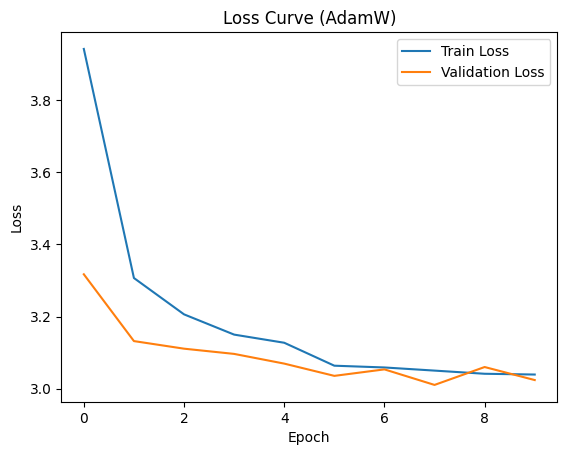

In [16]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (AdamW)")
plt.legend()
plt.show()

In [17]:
#save model
torch.save(model.state_dict(), "resnet18_tinyimagenet.pth")

In [18]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.3425


In [19]:
#start second frozen model --> modification = SGD optimizer
model_sgd = models.resnet18(pretrained=True)

#freeze backbone
for param in model_sgd.parameters():
    param.requires_grad = False

#replace classifier with SGD
model_sgd.fc = nn.Linear(model_sgd.fc.in_features, 200)
model_sgd = model_sgd.to(device)

#initialize SGD optimizer
optimizer_sgd = optim.SGD(
    model_sgd.fc.parameters(),
    lr=0.01,
    momentum=0.9
)
#redefine same loss and scheduler
criterion = nn.CrossEntropyLoss()

scheduler_sgd = optim.lr_scheduler.StepLR(
    optimizer_sgd,
    step_size=5,
    gamma=0.1
)

In [20]:
model_sgd, train_losses_sgd, val_losses_sgd = train_model(
    model_sgd,
    dataloaders,
    criterion,
    optimizer_sgd,
    scheduler_sgd,
    device,
    num_epochs=10
)


Epoch 1/10
--------------------
train Loss: 3.6888 Acc: 0.2364
val Loss: 3.5068 Acc: 0.2942

Epoch 2/10
--------------------
train Loss: 3.4541 Acc: 0.2754
val Loss: 3.5194 Acc: 0.3010

Epoch 3/10
--------------------
train Loss: 3.4309 Acc: 0.2790
val Loss: 3.4298 Acc: 0.3101

Epoch 4/10
--------------------
train Loss: 3.4124 Acc: 0.2838
val Loss: 3.4951 Acc: 0.3000

Epoch 5/10
--------------------
train Loss: 3.4062 Acc: 0.2850
val Loss: 3.4926 Acc: 0.3028

Epoch 6/10
--------------------
train Loss: 3.1509 Acc: 0.3173
val Loss: 3.1903 Acc: 0.3406

Epoch 7/10
--------------------
train Loss: 3.0862 Acc: 0.3251
val Loss: 3.1427 Acc: 0.3402

Epoch 8/10
--------------------
train Loss: 3.0662 Acc: 0.3279
val Loss: 3.1108 Acc: 0.3386

Epoch 9/10
--------------------
train Loss: 3.0383 Acc: 0.3309
val Loss: 3.0918 Acc: 0.3427

Epoch 10/10
--------------------
train Loss: 3.0247 Acc: 0.3321
val Loss: 3.0949 Acc: 0.3396


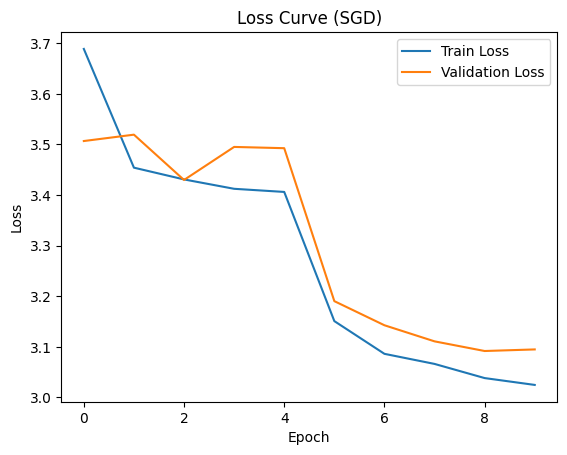

In [21]:
plt.plot(train_losses_sgd, label="Train Loss")
plt.plot(val_losses_sgd, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (SGD)")
plt.legend()
plt.show()

In [22]:
model_sgd.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_sgd(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.3396


In [23]:
model_l4unfreeze = models.resnet18(pretrained=True)

# Freeze everything
for param in model_l4unfreeze.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_l4unfreeze.layer4.parameters():
    param.requires_grad = True

# Replace classifier
model_l4unfreeze.fc = nn.Linear(model_l4unfreeze.fc.in_features, 200)

# Unfreeze fc
for param in model_l4unfreeze.fc.parameters():
    param.requires_grad = True

model_l4unfreeze = model_l4unfreeze.to(device)

# ✅ Optimizer with BOTH layer4 + fc
optimizer_l4unfreeze = optim.AdamW([
    {"params": model_l4unfreeze.layer4.parameters(), "lr": 1e-4},
    {"params": model_l4unfreeze.fc.parameters(), "lr": 3e-4}
])

# Loss + scheduler
criterion = nn.CrossEntropyLoss()
scheduler_l4unfreeze = optim.lr_scheduler.StepLR(optimizer_l4unfreeze, step_size=5, gamma=0.1)


In [24]:
model_l4unfreeze, train_losses_l4, val_losses_l4 = train_model(
    model_l4unfreeze,
    dataloaders,
    criterion,
    optimizer_l4unfreeze,
    scheduler_l4unfreeze,
    device,
    num_epochs=10
)


Epoch 1/10
--------------------
train Loss: 3.2103 Acc: 0.2882
val Loss: 2.5431 Acc: 0.3974

Epoch 2/10
--------------------
train Loss: 2.6333 Acc: 0.3834
val Loss: 2.3703 Acc: 0.4305

Epoch 3/10
--------------------
train Loss: 2.4917 Acc: 0.4108
val Loss: 2.3639 Acc: 0.4415

Epoch 4/10
--------------------
train Loss: 2.3927 Acc: 0.4295
val Loss: 2.2680 Acc: 0.4595

Epoch 5/10
--------------------
train Loss: 2.3246 Acc: 0.4422
val Loss: 2.2197 Acc: 0.4709

Epoch 6/10
--------------------
train Loss: 2.1746 Acc: 0.4763
val Loss: 2.1531 Acc: 0.4854

Epoch 7/10
--------------------
train Loss: 2.1162 Acc: 0.4901
val Loss: 2.1090 Acc: 0.4908

Epoch 8/10
--------------------
train Loss: 2.0908 Acc: 0.4936
val Loss: 2.1073 Acc: 0.4932

Epoch 9/10
--------------------
train Loss: 2.0865 Acc: 0.4955
val Loss: 2.1067 Acc: 0.4938

Epoch 10/10
--------------------
train Loss: 2.0578 Acc: 0.4998
val Loss: 2.0975 Acc: 0.4950


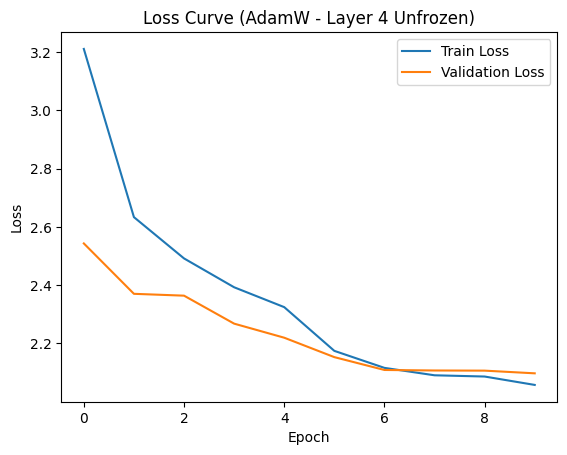

In [25]:
plt.plot(train_losses_l4, label="Train Loss")
plt.plot(val_losses_l4, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (AdamW - Layer 4 Unfrozen)")
plt.legend()
plt.show()

In [26]:
model_l4unfreeze.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_l4unfreeze(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.4950


In [33]:
model_ufsgd = models.resnet18(pretrained=True)

# Freeze everything
for param in model_ufsgd.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_ufsgd.layer4.parameters():
    param.requires_grad = True

# Replace classifier
model_ufsgd.fc = nn.Linear(model_ufsgd.fc.in_features, 200)

# Unfreeze fc
for param in model_ufsgd.fc.parameters():
    param.requires_grad = True

model_ufsgd = model_ufsgd.to(device)

optimizer_ufsgd = optim.SGD([
    {"params": model_ufsgd.layer4.parameters(), "lr": 1e-3},
    {"params": model_ufsgd.fc.parameters(), "lr": 1e-2}
], momentum=0.9)

# Loss + scheduler
criterion = nn.CrossEntropyLoss()
scheduler_ufsgd = optim.lr_scheduler.StepLR(optimizer_ufsgd, step_size=5, gamma=0.1)

In [34]:
model_ufsgd, train_losses_ufsgd, val_losses_ufsgd = train_model(
    model_ufsgd,
    dataloaders,
    criterion,
    optimizer_ufsgd,
    scheduler_ufsgd,
    device,
    num_epochs=10
)


Epoch 1/10
--------------------
train Loss: 3.3003 Acc: 0.2810
val Loss: 2.8526 Acc: 0.3707

Epoch 2/10
--------------------
train Loss: 2.8287 Acc: 0.3550
val Loss: 2.5845 Acc: 0.4039

Epoch 3/10
--------------------
train Loss: 2.6496 Acc: 0.3824
val Loss: 2.4776 Acc: 0.4220

Epoch 4/10
--------------------
train Loss: 2.5396 Acc: 0.4038
val Loss: 2.4157 Acc: 0.4380

Epoch 5/10
--------------------
train Loss: 2.4606 Acc: 0.4190
val Loss: 2.3559 Acc: 0.4466

Epoch 6/10
--------------------
train Loss: 2.2822 Acc: 0.4551
val Loss: 2.2484 Acc: 0.4650

Epoch 7/10
--------------------
train Loss: 2.2509 Acc: 0.4588
val Loss: 2.2378 Acc: 0.4706

Epoch 8/10
--------------------
train Loss: 2.2311 Acc: 0.4631
val Loss: 2.2030 Acc: 0.4726

Epoch 9/10
--------------------
train Loss: 2.2242 Acc: 0.4647
val Loss: 2.2226 Acc: 0.4718

Epoch 10/10
--------------------
train Loss: 2.2226 Acc: 0.4660
val Loss: 2.1980 Acc: 0.4793


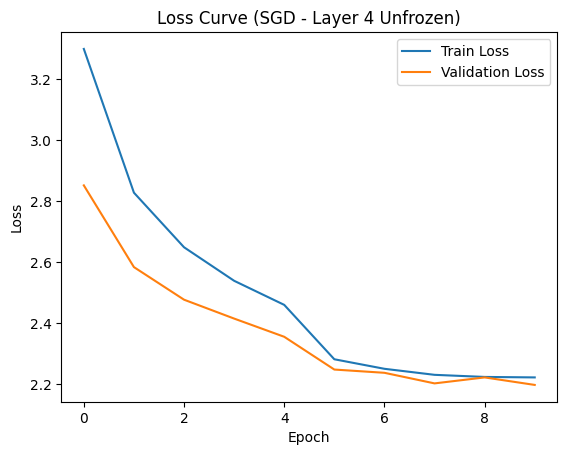

In [35]:
plt.plot(train_losses_ufsgd, label="Train Loss")
plt.plot(val_losses_ufsgd, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (SGD - Layer 4 Unfrozen)")
plt.legend()
plt.show()

In [36]:
model_ufsgd.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_ufsgd(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.4793


In [40]:
#most flexibility - unfrozen layer 3, longer training, no scheduler
model_l3unfreeze = models.resnet18(pretrained=True)

# Freeze everything
for param in model_l3unfreeze.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_l3unfreeze.layer4.parameters():
    param.requires_grad = True

# unfreeze layer 3
for param in model_l3unfreeze.layer3.parameters():
    param.requires_grad = True

# Replace classifier
model_l3unfreeze.fc = nn.Linear(model_l3unfreeze.fc.in_features, 200)

# Unfreeze fc
for param in model_l3unfreeze.fc.parameters():
    param.requires_grad = True

model_l3unfreeze = model_l3unfreeze.to(device)

# ✅ Optimizer with layer 3 + layer4 + fc
optimizer_l3unfreeze = optim.AdamW([
    {"params": model_l3unfreeze.layer4.parameters(), "lr": 1e-4},
    {"params": model_l3unfreeze.layer3.parameters(), "lr": 1e-4},
    {"params": model_l3unfreeze.fc.parameters(), "lr": 3e-4}
])

# Loss + dummy scheduler
criterion = nn.CrossEntropyLoss()
class DummyScheduler:
  def step(self):
    pass

scheduler_l3unfreeze = DummyScheduler()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [41]:
model_l3unfreeze, train_losses_l3, val_losses_l3 = train_model(
    model_l3unfreeze,
    dataloaders,
    criterion,
    optimizer_l3unfreeze,
    scheduler_l3unfreeze,
    device,
    num_epochs=30
)


Epoch 1/30
--------------------
train Loss: 3.1081 Acc: 0.3078
val Loss: 2.3644 Acc: 0.4314

Epoch 2/30
--------------------
train Loss: 2.5341 Acc: 0.4033
val Loss: 2.2445 Acc: 0.4649

Epoch 3/30
--------------------
train Loss: 2.3766 Acc: 0.4353
val Loss: 2.1507 Acc: 0.4788

Epoch 4/30
--------------------
train Loss: 2.2842 Acc: 0.4542
val Loss: 2.1073 Acc: 0.4932

Epoch 5/30
--------------------
train Loss: 2.2162 Acc: 0.4660
val Loss: 2.1090 Acc: 0.4969

Epoch 6/30
--------------------
train Loss: 2.1452 Acc: 0.4813
val Loss: 2.0912 Acc: 0.4980

Epoch 7/30
--------------------
train Loss: 2.0987 Acc: 0.4914
val Loss: 2.0860 Acc: 0.5084

Epoch 8/30
--------------------
train Loss: 2.0518 Acc: 0.5011
val Loss: 2.0732 Acc: 0.5105

Epoch 9/30
--------------------
train Loss: 2.0109 Acc: 0.5103
val Loss: 2.0674 Acc: 0.5148

Epoch 10/30
--------------------
train Loss: 1.9677 Acc: 0.5198
val Loss: 2.0621 Acc: 0.5115

Epoch 11/30
--------------------
train Loss: 1.9285 Acc: 0.5285
val 

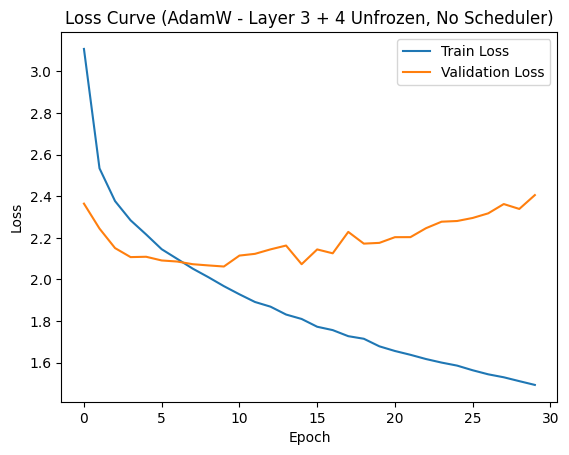

In [42]:
plt.plot(train_losses_l3, label="Train Loss")
plt.plot(val_losses_l3, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (AdamW - Layer 3 + 4 Unfrozen, No Scheduler)")
plt.legend()
plt.show()

In [43]:
model_l3unfreeze.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_l3unfreeze(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.5138


In [45]:
#most flexibility - SGD unfrozen layer 3, longer training, no scheduler
model_l3sgd = models.resnet18(pretrained=True)

# Freeze everything
for param in model_l3sgd.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_l3sgd.layer4.parameters():
    param.requires_grad = True

# unfreeze layer 3
for param in model_l3sgd.layer3.parameters():
    param.requires_grad = True

# Replace classifier
model_l3sgd.fc = nn.Linear(model_l3sgd.fc.in_features, 200)

# Unfreeze fc
for param in model_l3sgd.fc.parameters():
    param.requires_grad = True

model_l3sgd = model_l3sgd.to(device)

# ✅ Optimizer with layer 3 + layer4 + fc
optimizer_l3sgd = optim.SGD([
    {"params": model_l3sgd.layer3.parameters(), "lr": 1e-3},
    {"params": model_l3sgd.layer4.parameters(), "lr": 1e-3},
    {"params": model_l3sgd.fc.parameters(), "lr": 1e-2}
], momentum=0.9)

# Loss + dummy scheduler
criterion = nn.CrossEntropyLoss()
class DummyScheduler:
  def step(self):
    pass

scheduler_l3sgd = DummyScheduler()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [47]:
model_l3sgd, train_losses_l3sgd, val_losses_l3sgd = train_model(
    model_l3sgd,
    dataloaders,
    criterion,
    optimizer_l3sgd,
    scheduler_l3sgd,
    device,
    num_epochs=30
)


Epoch 1/30
--------------------
train Loss: 2.7696 Acc: 0.3674
val Loss: 2.5080 Acc: 0.4293

Epoch 2/30
--------------------
train Loss: 2.5251 Acc: 0.4103
val Loss: 2.3443 Acc: 0.4554

Epoch 3/30
--------------------
train Loss: 2.3973 Acc: 0.4321
val Loss: 2.2102 Acc: 0.4776

Epoch 4/30
--------------------
train Loss: 2.3112 Acc: 0.4507
val Loss: 2.1647 Acc: 0.4868

Epoch 5/30
--------------------
train Loss: 2.2402 Acc: 0.4640
val Loss: 2.1062 Acc: 0.4961

Epoch 6/30
--------------------
train Loss: 2.1874 Acc: 0.4724
val Loss: 2.1225 Acc: 0.4932

Epoch 7/30
--------------------
train Loss: 2.1415 Acc: 0.4828
val Loss: 2.1143 Acc: 0.5028

Epoch 8/30
--------------------
train Loss: 2.1008 Acc: 0.4902
val Loss: 2.0491 Acc: 0.5137

Epoch 9/30
--------------------
train Loss: 2.0589 Acc: 0.4990
val Loss: 2.0916 Acc: 0.5064

Epoch 10/30
--------------------
train Loss: 2.0274 Acc: 0.5049
val Loss: 2.0560 Acc: 0.5182

Epoch 11/30
--------------------
train Loss: 1.9924 Acc: 0.5127
val 

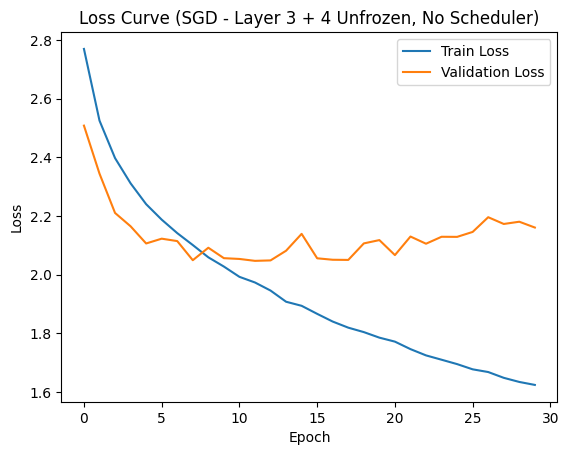

In [48]:
plt.plot(train_losses_l3sgd, label="Train Loss")
plt.plot(val_losses_l3sgd, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (SGD - Layer 3 + 4 Unfrozen, No Scheduler)")
plt.legend()
plt.show()

In [49]:
model_l3sgd.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_l3sgd(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.5316


In [50]:
# fix overfitting - dropout classifier and weight decay
model_adrop = models.resnet18(pretrained=True)

# Freeze all layers initially
for param in model_adrop.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_adrop.layer4.parameters():
    param.requires_grad = True

# Unfreeze layer3
for param in model_adrop.layer3.parameters():
    param.requires_grad = True

# Replace classifier with dropout
model_adrop.fc = nn.Sequential(
    nn.Linear(model_adrop.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),  # Dropout layer added
    nn.Linear(512, 200)
)

# Unfreeze fc parameters (all layers in the Sequential)
for param in model_adrop.fc.parameters():
    param.requires_grad = True

model_adrop = model_adrop.to(device)

# ✅ Optimizer with weight decay for regularization
optimizer_adrop = optim.AdamW([
    {"params": model_adrop.layer3.parameters(), "lr": 1e-4},
    {"params": model_adrop.layer4.parameters(), "lr": 1e-4},
    {"params": model_adrop.fc.parameters(), "lr": 3e-4}
], weight_decay=1e-4)  # weight decay added

# Loss + dummy scheduler
criterion = nn.CrossEntropyLoss()

class DummyScheduler:
    def step(self):
        pass

scheduler_adrop = DummyScheduler()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [51]:
model_adrop, train_losses_adrop, val_losses_adrop = train_model(
    model_adrop,
    dataloaders,
    criterion,
    optimizer_adrop,
    scheduler_adrop,
    device,
    num_epochs=30
)


Epoch 1/30
--------------------
train Loss: 3.4479 Acc: 0.2465
val Loss: 2.4805 Acc: 0.4123

Epoch 2/30
--------------------
train Loss: 2.8055 Acc: 0.3581
val Loss: 2.2840 Acc: 0.4571

Epoch 3/30
--------------------
train Loss: 2.6576 Acc: 0.3860
val Loss: 2.2417 Acc: 0.4642

Epoch 4/30
--------------------
train Loss: 2.5640 Acc: 0.4041
val Loss: 2.1982 Acc: 0.4759

Epoch 5/30
--------------------
train Loss: 2.5068 Acc: 0.4201
val Loss: 2.1751 Acc: 0.4864

Epoch 6/30
--------------------
train Loss: 2.4367 Acc: 0.4345
val Loss: 2.1453 Acc: 0.4896

Epoch 7/30
--------------------
train Loss: 2.4039 Acc: 0.4404
val Loss: 2.1335 Acc: 0.4948

Epoch 8/30
--------------------
train Loss: 2.3570 Acc: 0.4497
val Loss: 2.1193 Acc: 0.4989

Epoch 9/30
--------------------
train Loss: 2.3314 Acc: 0.4559
val Loss: 2.1391 Acc: 0.5008

Epoch 10/30
--------------------
train Loss: 2.2914 Acc: 0.4628
val Loss: 2.1127 Acc: 0.5013

Epoch 11/30
--------------------
train Loss: 2.2692 Acc: 0.4689
val 

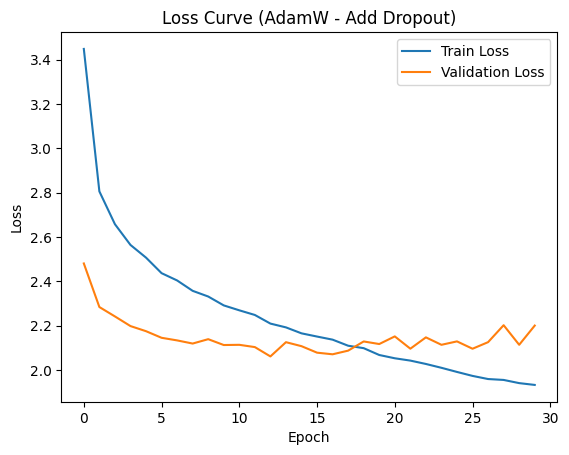

In [52]:
plt.plot(train_losses_adrop, label="Train Loss")
plt.plot(val_losses_adrop, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (AdamW - Add Dropout)")
plt.legend()
plt.show()

In [53]:
model_adrop.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_adrop(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.5228


In [54]:
# Fix SGD overfitting - add dropout (0.6) in classifier, weight decay
model_sgddrop = models.resnet18(pretrained=True)

# Freeze all layers initially
for param in model_sgddrop.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_sgddrop.layer4.parameters():
    param.requires_grad = True

# Unfreeze layer3
for param in model_sgddrop.layer3.parameters():
    param.requires_grad = True

# Replace classifier with dropout
model_sgddrop.fc = nn.Sequential(
    nn.Linear(model_sgddrop.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.6),  # stronger dropout to reduce overfitting
    nn.Linear(512, 200)
)

# Unfreeze all parameters in the new fc
for param in model_sgddrop.fc.parameters():
    param.requires_grad = True

model_sgddrop = model_sgddrop.to(device)

# ✅ Optimizer with weight decay for regularization
optimizer_sgddrop = optim.SGD([
    {"params": model_sgddrop.layer3.parameters(), "lr": 1e-3},
    {"params": model_sgddrop.layer4.parameters(), "lr": 1e-3},
    {"params": model_sgddrop.fc.parameters(), "lr": 1e-2}
], momentum=0.9, weight_decay=1e-4)  # same weight decay added

# Loss + dummy scheduler
criterion = nn.CrossEntropyLoss()

class DummyScheduler:
    def step(self):
        pass

scheduler_sgddrop = DummyScheduler()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [56]:
model_sgddrop, train_losses_sgddrop, val_losses_sgddrop = train_model(
    model_sgddrop,
    dataloaders,
    criterion,
    optimizer_sgddrop,
    scheduler_sgddrop,
    device,
    num_epochs=30
)


Epoch 1/30
--------------------
train Loss: 2.5493 Acc: 0.4155
val Loss: 2.0664 Acc: 0.5027

Epoch 2/30
--------------------
train Loss: 2.5072 Acc: 0.4237
val Loss: 2.0611 Acc: 0.5053

Epoch 3/30
--------------------
train Loss: 2.4872 Acc: 0.4286
val Loss: 2.0735 Acc: 0.4985

Epoch 4/30
--------------------
train Loss: 2.4475 Acc: 0.4357
val Loss: 2.0325 Acc: 0.5071

Epoch 5/30
--------------------
train Loss: 2.4242 Acc: 0.4398
val Loss: 2.0385 Acc: 0.5094

Epoch 6/30
--------------------
train Loss: 2.4028 Acc: 0.4462
val Loss: 2.0512 Acc: 0.5117

Epoch 7/30
--------------------
train Loss: 2.3687 Acc: 0.4507
val Loss: 2.0506 Acc: 0.5065

Epoch 8/30
--------------------
train Loss: 2.3562 Acc: 0.4545
val Loss: 2.0062 Acc: 0.5154

Epoch 9/30
--------------------
train Loss: 2.3313 Acc: 0.4595
val Loss: 1.9940 Acc: 0.5223

Epoch 10/30
--------------------
train Loss: 2.3195 Acc: 0.4628
val Loss: 2.0361 Acc: 0.5156

Epoch 11/30
--------------------
train Loss: 2.3031 Acc: 0.4684
val 

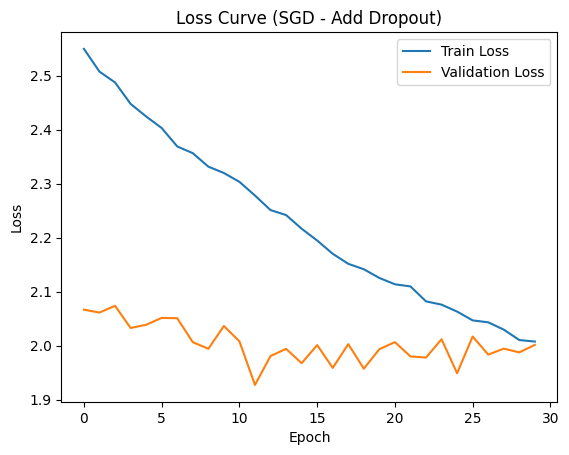

In [57]:
plt.plot(train_losses_sgddrop, label="Train Loss")
plt.plot(val_losses_sgddrop, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (SGD - Add Dropout)")
plt.legend()
plt.show()

In [58]:
model_sgddrop.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_sgddrop(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.5351


In [14]:
# try hyperparameters on ResNet-34
model_adam34 = models.resnet34(pretrained=True)

# Freeze all layers initially
for param in model_adam34.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_adam34.layer4.parameters():
    param.requires_grad = True

# Unfreeze layer3
for param in model_adam34.layer3.parameters():
    param.requires_grad = True

# Replace classifier with dropout
model_adam34.fc = nn.Sequential(
    nn.Linear(model_adam34.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),  # Dropout layer added
    nn.Linear(512, 200)
)

# Unfreeze fc parameters (all layers in the Sequential)
for param in model_adam34.fc.parameters():
    param.requires_grad = True

model_adam34 = model_adam34.to(device)

# ✅ Optimizer with weight decay for regularization
optimizer_adam34 = optim.AdamW([
    {"params": model_adam34.layer3.parameters(), "lr": 5e-5},
    {"params": model_adam34.layer4.parameters(), "lr": 5e-5},
    {"params": model_adam34.fc.parameters(), "lr": 2e-4}
], weight_decay=1e-4)  # weight decay added

# Loss + dummy scheduler
criterion = nn.CrossEntropyLoss()

class DummyScheduler:
    def step(self):
        pass

scheduler_adam34 = DummyScheduler()

In [15]:
model_adam34, train_losses_adam34, val_losses_adam34 = train_model(
    model_adam34,
    dataloaders,
    criterion,
    optimizer_adam34,
    scheduler_adam34,
    device,
    num_epochs=30
)


Epoch 1/30
--------------------
train Loss: 3.4007 Acc: 0.2604
val Loss: 2.2755 Acc: 0.4563

Epoch 2/30
--------------------
train Loss: 2.6494 Acc: 0.3926
val Loss: 2.0931 Acc: 0.4981

Epoch 3/30
--------------------
train Loss: 2.4752 Acc: 0.4277
val Loss: 2.0628 Acc: 0.5010

Epoch 4/30
--------------------
train Loss: 2.3636 Acc: 0.4511
val Loss: 2.0588 Acc: 0.5119

Epoch 5/30
--------------------
train Loss: 2.2816 Acc: 0.4692
val Loss: 1.9591 Acc: 0.5310

Epoch 6/30
--------------------
train Loss: 2.2290 Acc: 0.4809
val Loss: 1.9425 Acc: 0.5386

Epoch 7/30
--------------------
train Loss: 2.1739 Acc: 0.4902
val Loss: 1.9244 Acc: 0.5332

Epoch 8/30
--------------------
train Loss: 2.1357 Acc: 0.4986
val Loss: 1.9273 Acc: 0.5445

Epoch 9/30
--------------------
train Loss: 2.0936 Acc: 0.5060
val Loss: 1.9101 Acc: 0.5429

Epoch 10/30
--------------------
train Loss: 2.0528 Acc: 0.5164
val Loss: 1.9006 Acc: 0.5503

Epoch 11/30
--------------------
train Loss: 2.0232 Acc: 0.5214
val 

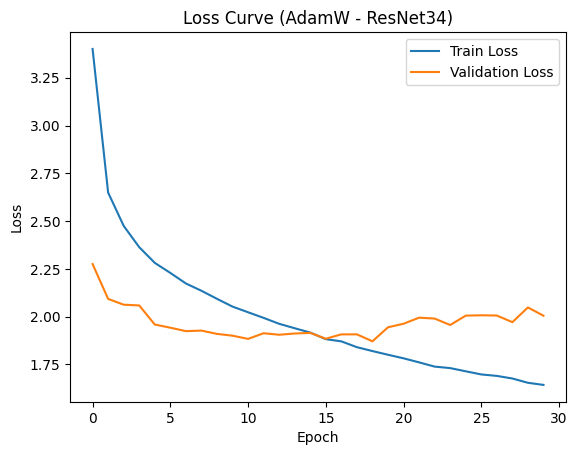

In [17]:
import matplotlib.pyplot as plt

plt.plot(train_losses_adam34, label="Train Loss")
plt.plot(val_losses_adam34, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (AdamW - ResNet34)")
plt.legend()
plt.show()

In [18]:
model_adam34.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_adam34(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.5684


In [19]:
# SGD and altered hyperparameters in ResNet-34
model_sgd34 = models.resnet34(pretrained=True)

# Freeze all layers initially
for param in model_sgd34.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_sgd34.layer4.parameters():
    param.requires_grad = True

# Unfreeze layer3
for param in model_sgd34.layer3.parameters():
    param.requires_grad = True

# Replace classifier with dropout
model_sgd34.fc = nn.Sequential(
    nn.Linear(model_sgd34.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.6),  # stronger dropout to reduce overfitting
    nn.Linear(512, 200)
)

# Unfreeze all parameters in the new fc
for param in model_sgd34.fc.parameters():
    param.requires_grad = True

model_sgd34 = model_sgd34.to(device)

# ✅ Optimizer with weight decay for regularization
optimizer_sgd34 = optim.SGD([
    {"params": model_sgd34.layer3.parameters(), "lr": 5e-4},
    {"params": model_sgd34.layer4.parameters(), "lr": 5e-4},
    {"params": model_sgd34.fc.parameters(), "lr":5e-3}
], momentum=0.9, weight_decay=1e-4)  # same weight decay added

# Loss + dummy scheduler
criterion = nn.CrossEntropyLoss()

class DummyScheduler:
    def step(self):
        pass

scheduler_sgd34 = DummyScheduler()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [20]:
model_sgd34, train_losses_sgd34, val_losses_sgd34 = train_model(
    model_sgd34,
    dataloaders,
    criterion,
    optimizer_sgd34,
    scheduler_sgd34,
    device,
    num_epochs=30
)


Epoch 1/30
--------------------
train Loss: 3.6585 Acc: 0.2183
val Loss: 2.4408 Acc: 0.4186

Epoch 2/30
--------------------
train Loss: 2.8654 Acc: 0.3489
val Loss: 2.2237 Acc: 0.4644

Epoch 3/30
--------------------
train Loss: 2.7095 Acc: 0.3812
val Loss: 2.1452 Acc: 0.4830

Epoch 4/30
--------------------
train Loss: 2.6092 Acc: 0.4013
val Loss: 2.0647 Acc: 0.5016

Epoch 5/30
--------------------
train Loss: 2.5566 Acc: 0.4143
val Loss: 1.9843 Acc: 0.5213

Epoch 6/30
--------------------
train Loss: 2.4951 Acc: 0.4279
val Loss: 2.0297 Acc: 0.5138

Epoch 7/30
--------------------
train Loss: 2.4448 Acc: 0.4367
val Loss: 1.9839 Acc: 0.5251

Epoch 8/30
--------------------
train Loss: 2.4011 Acc: 0.4471
val Loss: 1.9767 Acc: 0.5301

Epoch 9/30
--------------------
train Loss: 2.3676 Acc: 0.4532
val Loss: 1.9231 Acc: 0.5399

Epoch 10/30
--------------------
train Loss: 2.3353 Acc: 0.4609
val Loss: 1.9659 Acc: 0.5305

Epoch 11/30
--------------------
train Loss: 2.3016 Acc: 0.4668
val 

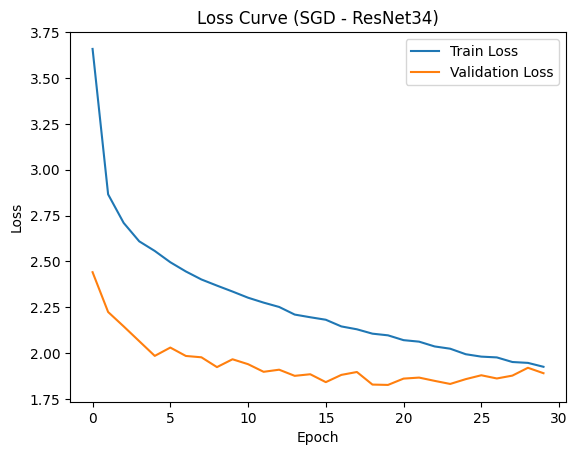

In [21]:
plt.plot(train_losses_sgd34, label="Train Loss")
plt.plot(val_losses_sgd34, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (SGD - ResNet34)")
plt.legend()
plt.show()

In [22]:
model_sgd34.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_sgd34(inputs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.5702
